# Script to compute summer metrics from GFDL-ESM4 data over historical period + 2015-2024 using SSP2-4.5

In [3]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft

from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

###################
# helper functions
###################
def SummerStatsFourier(temp_data, temp_data_next, threshold, save_plot, calc_tmax, calc_heat):
    '''

    Function that uses the input 75th percentile temperature in K to identify the summer from a time series of temperatures.
    Input data should already be set to 365 days.

    Args:
        temp_data: xarray of temperature data for a single grid cell for the year of interest
        temp_data_next: xarray of temperature data for a single grid cell for the following year (for SH summers)
        threshold: xarray for the 75th percentile threshold to use
        save_plot: save out a png of the time series with threshold, day of max, summer start/end shown
        calc_tmax: should the day of max temp during summer be calculated (slows processing)
        calc_heat: should the accumulated heat during summer be calculated (slows processing), includes mean temp and mean HS temp
        
    Returns:
        start day: DOY that daily mean t2m (from smoothed Fourier fit) first crossed above threshold (75th percentile)
        end day: DOY that daily mean t2m (from smoothed Fourier fit) first crossed below threshold (75th percentile) 
        day with max temp: during the summer period, the day that had the highest mean daily t2m 
        accumulated heat in summer: sum of degree days above threshold during summer, 0 if none
        summer length: number of days the smoothed fit to the t2m data is above threshold, 0 if none
        rmse: root mean squared error of Fourier fit to temperature time series
        **** r2: R-squared value for Fourier fit [IS THIS POSSIBLE???]
        mean temp: the mean temperature in K for the summer period, 0 if there was no time above threshold
        mean HS temp: the mean temperature in K for the days above threshold during summer (positive days)
        
    Example:
        start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs = SummerStats(temps, temps_next, thresh, True, True, False)

    '''

    # default values
    first_day = 0 
    last_day = 0
    tmax_day = 0 
    summer_heat = 0 
    summer_length = 0
    rmse = 0.0
    r_squared = 0.0 # keeping for backward compat with the poly fit outputs
    mean_t = 0
    mean_hs = 0

    # split method based on NH or SH

    ######
    # Northern Hemisphere (uses current year only)
    if temp_data.lat.values >= 0:
        # extract DOY and T2m values for those days
        x1 = temp_data.time.dt.dayofyear.values
        y1 = temp_data.values

        # Fourier fit, up to 4th harmonic (mean + 3 more) as in Weller et al 2020
        ymean = np.mean(y1)
        y_norm = y1 - ymean
        # perform DFT of temp data
        coef = fft(y_norm)
        # low-pass filter: retain only the mean and the first three harmonics, set all other frequencies to zero
        # help from https://kls2177.github.io/Climate-and-Geophysical-Data-Analysis/chapters/Week6/filtering_in_freq2.html
        Z_lp = np.copy(coef)
        Z_lp[4:-3:] = 0.0  # we have to set both the positive and negative frequencies to zero
        # apply inverse fourier transform to convert back to time domain (just want the real part)
        y_norm_lp = np.real(np.fft.ifft(Z_lp))

        # add back in the original mean temp
        y_lp = y_norm_lp + ymean

        # RMSE for Fourier fit
        rmse = np.sqrt(np.sum((y1-y_lp)**2)/365.0)
    
        # create some x values for plotting  fit
        x_values = np.linspace(min(x1), max(x1), 365) 
    
        # use fit to get stats
        summer_length = np.count_nonzero(y_lp >= threshold.values)
        summer_days = np.where(y_lp >= threshold.values)[0]

        # deal with those that didn't have any days above threshold
        if summer_length == 0:
            first_day = 0
            last_day = 0
            if calc_tmax:
                # day with max temp isn't above threshold but still want the value so can be any day of the year
                tmax_day = int(temp_data.argmax() + 1)
            if calc_heat:
                # determine accumulated heat over summer as sum of degree days above threshold
                # in this case there are none
                summer_heat = 0
        else:
            # otherwise can get start/end days 
            first_day = int(x_values[min(summer_days)])
            #OLD:# last_day = int(x_values[max(summer_days)])

            # end day comes after first day so find next crossing of  fit
            # this is to be careful to not count until the end of a double crossing
            end_window = np.where((y_lp[first_day:365]) < threshold.values)

            # if it does cross back below threshold before the end of the "year"
            if np.count_nonzero(end_window):
                last_day = end_window[0][0] + first_day

            # otherwise it never crosses back below threshold for the "year"
            # so the last day is day 365
            else:
                last_day = 365
           
            # summer length is the span between first and last + 1 to include the end day
            summer_length = last_day - first_day + 1    
            
            if calc_tmax:
                # day with max temp that is in summer period
                if first_day == last_day: #only one day of summer
                    tmax_day = first_day
                else:
                    # if summer_length is 0 then we already grab the day of max temp in the year
                    # but the day of max can also be the last day of the year so have to special case
                    if (temp_data[(first_day):(last_day+1)]).size == 0:
                        tmax_day = last_day
                    else:         
                        tmax_day = int((temp_data[(first_day):(last_day+1)].argmax() + 1) + first_day)        
            if calc_heat:
                # determine accumulated heat over summer as sum of degree days above threshold
                # also save mean temp
                nh_summ = temp_data[(first_day):(last_day+1)]

                # total area relative to zero for regions above threshold line
                above_thresh = float(nh_summ.where(nh_summ.values >= threshold.values).sum())
                days_above_thresh = nh_summ.where(nh_summ.values >= threshold.values).count()
                
                # area below threshold line to be subtracted
                thresh_heat = float(nh_summ.where(nh_summ.values >= threshold.values).count()) * threshold.values
                
                # calculate difference to get only the area between threshold and data
                summer_heat = above_thresh - thresh_heat

                # if there is a summer we can get the mean temp for the whole summer and the mean HS temp
                if len(nh_summ) > 0:
                    mean_t = nh_summ.values.mean()
                    mean_hs = float(above_thresh/days_above_thresh) - threshold.values

                
    
    ######
    # Southern Hemisphere (uses current year and following year)
    else: 
        # concat both years
        ds_two = xr.concat([temp_data, temp_data_next], dim="time")

        # get the current year for slicing
        input_year = temp_data.time.dt.year.values[0]

        # select July 1 - June 30 across the two years to do fit
        startdate = str(input_year)+'-07-01' # 182nd day of a normal year
        enddate = str(input_year+1)+'-06-30'
        sh_yr = ds_two.sel(time=slice(startdate,enddate))
        
        # DOY (relative to July 1) and T2m values for those days
        x1 = np.arange(1,len(sh_yr.time)+1) 
        y1 = sh_yr.values
        
        # Fourier fit, up to 4th harmonic (mean + 3 more) as in Weller et al 2020
        ymean = np.mean(y1)
        y_norm = y1 - ymean
        # perform DFT of temp data
        coef = fft(y_norm)
        # low-pass filter: retain only the mean and the first three harmonics, set all other frequencies to zero
        # help from https://kls2177.github.io/Climate-and-Geophysical-Data-Analysis/chapters/Week6/filtering_in_freq2.html
        Z_lp = np.copy(coef)
        Z_lp[4:-3:] = 0.0  # we have to set both the positive and negative frequencies to zero
        # apply inverse fourier transform to convert back to time domain (just want the real part)
        y_norm_lp = np.real(np.fft.ifft(Z_lp))

        # add back in the original mean temp
        y_lp = y_norm_lp + ymean

        # RMSE for Fourier fit
        rmse = np.sqrt(np.sum((y1-y_lp)**2)/365.0)
        
        # create some x values for plotting  fit
        x_values = np.linspace(min(x1), max(x1), 365) 
        summer_length = np.count_nonzero(y_lp >= threshold.values)
        summer_days = np.where(y_lp >= threshold.values)[0]

        # check if summer length is 0
        if summer_length == 0:
            first_day = 0
            last_day = 0
            if calc_tmax:
                # day with max temp isn't above threshold but still want the value so can be any day of the year
                tmax_day = int(sh_yr.argmax() + 1)
            if calc_heat:
                # determine accumulated heat over summer as sum of degree days above threshold
                # in this case there are none
                summer_heat = 0
        else:
            # otherwise can get start/end days but note these are relative to July 1
            first_day = int(x_values[min(summer_days)])
            #OLD:# last_day = int(x_values[max(summer_days)])

            # end day comes after first day so find next crossing of  fit
            # this is to be careful to not count until the end of a double crossing
            end_window = np.where((y_lp[first_day:365]) < threshold.values)

            # if it does cross back below threshold before the end of the "year"
            if np.count_nonzero(end_window):
                last_day = end_window[0][0] + first_day

            # otherwise it never crosses back below threshold for the "year"
            # so the last day is day 365
            else:
                last_day = 365
           
            # summer length is the span between first and last + 1 to include the end day
            summer_length = last_day - first_day + 1           
    
            
            if calc_tmax:
                # day with max temp that is in summer period
                if first_day == last_day: #only one day of summer
                    tmax_day = first_day
                else:
                    # if summer_length is 0 then we already grab the day of max temp in the year
                    # but the day of max can also be the last day of the year so have to special case
                    if (sh_yr[(first_day):(last_day+1)]).size == 0:
                        tmax_day = last_day
                    else:         
                        tmax_day = int((sh_yr[(first_day):(last_day+1)].argmax() + 1) + first_day)  
            if calc_heat:
                # determine accumulated heat over summer as sum of degree days above threshold
                # also save the mean temp of summer
                sh_summ = sh_yr[(first_day):(last_day+1)]

                # total area relative to zero for regions above threshold line
                above_thresh = float(sh_summ.where(sh_summ.values >= threshold.values).sum())
                days_above_thresh = sh_summ.where(sh_summ.values >= threshold.values).count()
                
                # area below threshold line to be subtracted
                thresh_heat = float(sh_summ.where(sh_summ.values >= threshold.values).count()) * threshold.values
                
                # calculate difference to get only the area between threshold and data
                summer_heat = above_thresh - thresh_heat

                # if there is a summer we can get the mean temp for the whole summer and the mean HS temp
                if len(sh_summ) > 0:
                    mean_t = sh_summ.values.mean()
                    mean_hs = float(above_thresh/days_above_thresh) - threshold.values
                
                

                
    # make and save plot if desired
    ##
    ##
    if save_plot:
        cell_lat = temp_data.lat.values
        cell_lon = temp_data.lon.values
        yr = temp_data.time.dt.year.values[0]

        plt.figure(figsize=(16,6))
        plt.plot(x1,y1, label='daily mean T2m')
        plt.plot(x_values, y_lp, label='Fourier fit 1-4th Harmonic', color='red')
        plt.axhline(threshold.values, color="black", linewidth=0.8, linestyle="dashed") 
        plt.axvline(first_day, color="black", linewidth=0.8, linestyle="dashed")
        plt.axvline(last_day, color="black", linewidth=0.8, linestyle="dashed")
        plt.annotate('start', xy=(first_day-5,np.max(y_lp)+2), fontsize=12)
        plt.annotate('end', xy=(last_day-5,np.max(y_lp)+2), fontsize=12)
        plt.annotate('summer = '+str(summer_length)+' days', xy=(first_day+5,np.mean(y_lp)), fontsize=18)
        plt.annotate('75th percentile = '+str(np.round(threshold.values,1))+'K', xy=(0,threshold.values+1), fontsize=18)
        plt.annotate('RMSE = '+str(np.round(rmse,2)), xy=(0, np.min(y1)), fontsize=18)
        plt.annotate('Mean = '+str(np.round(mean_t,2))+'K', xy=(last_day-5, mean_t-1), fontsize=12)

        if calc_tmax:
            # add annotation for tmax_day
            plt.annotate('Tmax day '+str(tmax_day), xy=(tmax_day,np.max(y1)), fontsize=12)

        if cell_lat < 0:
            # SH days are relative to July 1
            plt.xlabel('DOY (' + str(yr) + ') relative to July 1')
        else:
            plt.xlabel('DOY (' + str(yr) + ')')
        plt.ylabel('Mean Daily Temp (K)')
        plt.title(str(yr) + " Summer for Lat,Lon = [" +str(cell_lat)+","+str(cell_lon)+ "] Baseline Years = (1961-1990)")
        plt.legend()
        plt.savefig("fourierfit_stats_"+str(cell_lat)+"_"+str(cell_lon)+"_"+str(yr)+".png")
        plt.show()
    
    # return
    return int(first_day), int(last_day), int(tmax_day), float(summer_heat), int(summer_length), float(rmse), float(r_squared), float(mean_t), float(mean_hs)



#### Load baseline 75% percentile values from ERA5 data per grid cell

In [10]:
# get baseline
file_path = '../../../Data/ERA5-global/Baseline/computed_1961-1990-full_75th.nc'
c_75 = xr.open_dataarray(file_path)
c_75.values


array([[236.4370575 , 236.4370575 , 236.4370575 , ..., 236.4370575 ,
        236.4370575 , 236.4370575 ],
       [236.18743896, 236.1893158 , 236.19142151, ..., 236.18388367,
        236.18530273, 236.18659973],
       [235.91021729, 235.9200592 , 235.92704773, ..., 235.88049316,
        235.8903656 , 235.90020752],
       ...,
       [270.7281189 , 270.72640991, 270.72720337, ..., 270.73239136,
        270.73184204, 270.73007202],
       [270.74356079, 270.74273682, 270.74200439, ..., 270.74594116,
        270.74508667, 270.74420166],
       [270.7550354 , 270.7550354 , 270.7550354 , ..., 270.7550354 ,
        270.7550354 , 270.7550354 ]], shape=(721, 1440))

In [27]:
c_75

<xarray.DataArray 't2m' (lat: 721, lon: 1440)> Size: 8MB
array([[236.437057, 236.437057, 236.437057, ..., 236.437057, 236.437057,
        236.437057],
       [236.187439, 236.189316, 236.191422, ..., 236.183884, 236.185303,
        236.1866  ],
       [235.910217, 235.920059, 235.927048, ..., 235.880493, 235.890366,
        235.900208],
       ...,
       [270.728119, 270.72641 , 270.727203, ..., 270.732391, 270.731842,
        270.730072],
       [270.743561, 270.742737, 270.742004, ..., 270.745941, 270.745087,
        270.744202],
       [270.755035, 270.755035, 270.755035, ..., 270.755035, 270.755035,
        270.755035]], shape=(721, 1440))
Coordinates:
  * lat       (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon       (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
    quantile  float64 8B ...
Attributes:
    long_name:  75th percentile 2m Temperature for the data across available ...
    units:      K

### Load CMIP6 data and fix coordinate issues

In [51]:
# all data so far
#file_path = '../../../Data/CMIP6/GFDL-ESM4/*.nc'
file_path = '../../../Data/CMIP6/GFDL-ESM4/tas_day_GFDL-ESM4_ssp245_r1i1p1f1_gr1_20150101-20241231.nc'

ds_gfdl = xr.open_mfdataset(file_path)

#### update time variable

In [52]:
ds_gfdl['time'] = ds_gfdl.indexes['time'].to_datetimeindex()

/var/folders/ml/p381h5fs0x9g7g5ksj8fh6qh0000gn/T/ipykernel_73769/1565888960.py:1: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  ds_gfdl['time'] = ds_gfdl.indexes['time'].to_datetimeindex()
/var/folders/ml/p381h5fs0x9g7g5ksj8fh6qh0000gn/T/ipykernel_73769/1565888960.py:1: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  ds_gfdl['time'] = ds_gfdl.indexes['time'].to_datetimeindex()


In [21]:
def missing_elements(L):
    start, end = L[0], L[-1]
    return sorted(set(range(start, end + 1)).difference(L))

L = ds_gfdl.sel(time='2000').time.dt.dayofyear.values
missing_elements(L)

[60]

#### Looks like Feb 29 has been removed

#### Adjust Lon to run from -180 to 180 instead of 0 to 360

In [53]:
# adjust longitude to run from -180 to 180
# solution from: https://stackoverflow.com/questions/53345442/about-changing-longitude-array-from-0-360-to-180-to-180-with-python-xarray
# save attributes so I can add them back later
lon_atrib = ds_gfdl.coords['lon'].attrs  
lat_atrib = ds_gfdl.coords['lat'].attrs
ds_gfdl.coords['lon'] = (ds_gfdl.coords['lon'] + 180) % 360 - 180
ds_fixed = ds_gfdl.sortby(ds_gfdl.lon)
ds_fixed

<xarray.Dataset> Size: 757MB
Dimensions:    (lat: 180, bnds: 2, lon: 288, time: 3650)
Coordinates:
  * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * bnds       (bnds) float64 16B 1.0 2.0
  * lon        (lon) float64 2kB -179.4 -178.1 -176.9 ... 176.9 178.1 179.4
  * time       (time) datetime64[ns] 29kB 2015-01-01T12:00:00 ... 2024-12-31T...
    height     float64 8B ...
Data variables:
    lat_bnds   (lat, bnds) float64 3kB dask.array<chunksize=(180, 2), meta=np.ndarray>
    lon_bnds   (lon, bnds) float64 5kB dask.array<chunksize=(288, 2), meta=np.ndarray>
    tas        (time, lat, lon) float32 757MB dask.array<chunksize=(1, 180, 288), meta=np.ndarray>
    time_bnds  (time, bnds) object 58kB dask.array<chunksize=(1, 2), meta=np.ndarray>
Attributes: (12/46)
    external_variables:     areacella
    history:                File was processed by fremetar (GFDL analog of CM...
    table_id:               day
    activity_id:            ScenarioMIP
    branch_method:          standard
    branch_time_in_child:   60225.0
    ...                     ...
    title:                  NOAA GFDL GFDL-ESM4 model output prepared for CMI...
    tracking_id:            hdl:21.14100/a94e308e-7b1b-4a67-a21a-aa57eb88f207
    variable_id:            tas
    variant_info:           N/A
    references:             see further_info_url attribute
    variant_label:          r1i1p1f1

#### Save out data with fixed time and longitude coords

In [54]:
file_path = '../../../Data/CMIP6/GFDL-ESM4/FixedCoords/tas_day_GFDL-ESM4_ssp245_r1i1p1f1_gr1_20150101-20241231.nc'

ds_fixed.to_netcdf(file_path)

## Now re-load fixed CMIP6 data

In [55]:
file_path = '../../../Data/CMIP6/GFDL-ESM4/FixedCoords/*.nc'
#file_path = '../../../Data/CMIP6/GFDL-ESM4/tas_day_GFDL-ESM4_ssp245_r1i1p1f1_gr1_20150101-20241231.nc'

ds_gfdl = xr.open_mfdataset(file_path)

/var/folders/ml/p381h5fs0x9g7g5ksj8fh6qh0000gn/T/ipykernel_73769/2520536347.py:4: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_gfdl = xr.open_mfdataset(file_path)


In [56]:
ds_gfdl

<xarray.Dataset> Size: 3GB
Dimensions:    (time: 12775, lat: 180, bnds: 2, lon: 288)
Coordinates:
  * time       (time) datetime64[ns] 102kB 1990-01-01T12:00:00 ... 2024-12-31...
  * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * bnds       (bnds) float64 16B 1.0 2.0
  * lon        (lon) float64 2kB -179.4 -178.1 -176.9 ... 176.9 178.1 179.4
    height     float64 8B 2.0
Data variables:
    lat_bnds   (time, lat, bnds) float64 37MB dask.array<chunksize=(1825, 180, 2), meta=np.ndarray>
    lon_bnds   (time, lon, bnds) float64 59MB dask.array<chunksize=(1825, 288, 2), meta=np.ndarray>
    tas        (time, lat, lon) float32 3GB dask.array<chunksize=(1, 180, 288), meta=np.ndarray>
    time_bnds  (time, bnds) object 204kB dask.array<chunksize=(1, 2), meta=np.ndarray>
Attributes: (12/46)
    external_variables:     areacella
    history:                File was processed by fremetar (GFDL analog of CM...
    table_id:               day
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    ...                     ...
    title:                  NOAA GFDL GFDL-ESM4 model output prepared for CMI...
    tracking_id:            hdl:21.14100/ef0a0372-2d5b-4290-89a9-83c849cfa64e
    variable_id:            tas
    variant_info:           N/A
    references:             see further_info_url attribute
    variant_label:          r1i1p1f1

### Test for Vancouver 2000 - nearest grid cell

In [63]:
#test for Vancouver
input_lat = 49.246
input_lon = -123.116

thresh = c_75.sel(lat=input_lat, lon=input_lon, method="nearest")
thresh

<xarray.DataArray 't2m' ()> Size: 8B
array(286.88797)
Coordinates:
    lat       float64 8B 49.25
    lon       float64 8B -123.0
    quantile  float64 8B ...
Attributes:
    long_name:  75th percentile 2m Temperature for the data across available ...
    units:      K

In [64]:
input_year = 2000

ds = ds_gfdl.sel(time = str(input_year))
curr = ds.tas.sel(lat=input_lat, lon=input_lon, method="nearest")
dsnext = ds_gfdl.sel(time = str(input_year+1))
nxt = dsnext.tas.sel(lat=input_lat, lon=input_lon, method="nearest")
curr, nxt

(<xarray.DataArray 'tas' (time: 365)> Size: 1kB
 dask.array<getitem, shape=(365,), dtype=float32, chunksize=(1,), chunktype=numpy.ndarray>
 Coordinates:
   * time     (time) datetime64[ns] 3kB 2000-01-01T12:00:00 ... 2000-12-31T12:...
     height   float64 8B 2.0
     lat      float64 8B 49.5
     lon      float64 8B -123.1
 Attributes:
     long_name:      Near-Surface Air Temperature
     units:          K
     cell_methods:   area: time: mean
     cell_measures:  area: areacella
     standard_name:  air_temperature
     interp_method:  conserve_order2
     original_name:  tas,
 <xarray.DataArray 'tas' (time: 365)> Size: 1kB
 dask.array<getitem, shape=(365,), dtype=float32, chunksize=(1,), chunktype=numpy.ndarray>
 Coordinates:
   * time     (time) datetime64[ns] 3kB 2001-01-01T12:00:00 ... 2001-12-31T12:...
     height   float64 8B 2.0
     lat      float64 8B 49.5
     lon      float64 8B -123.1
 Attributes:
     long_name:      Near-Surface Air Temperature
     units:          K
 

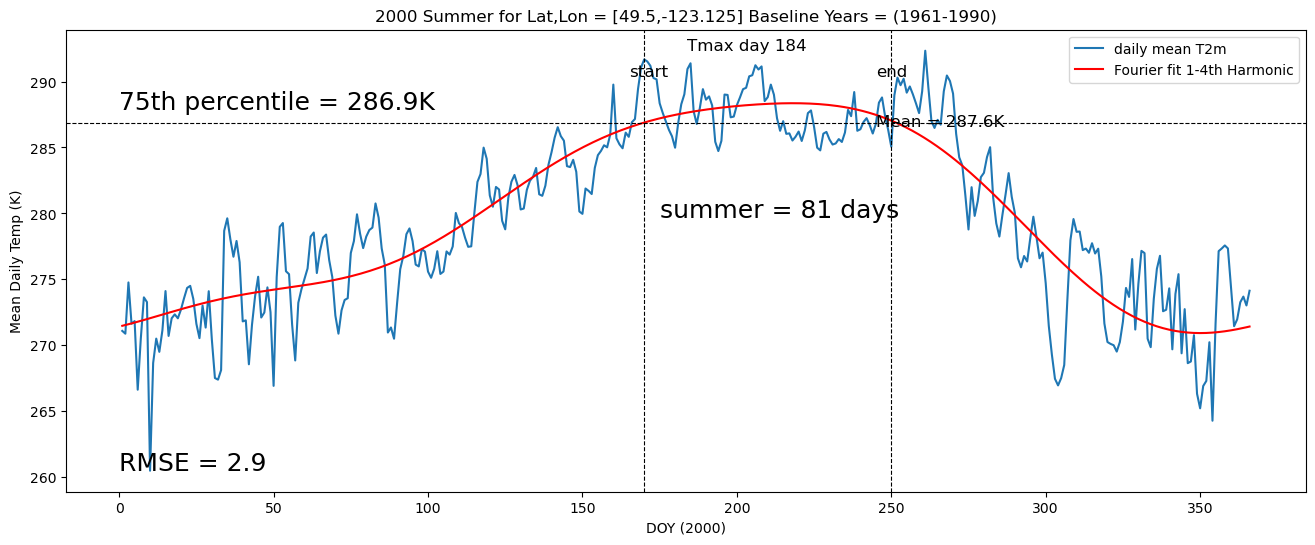

(170,
 250,
 184,
 92.30740356445312,
 81,
 2.896641969680786,
 0.0,
 287.6014099121094,
 1.9639873098819862)

In [65]:
start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs = SummerStatsFourier(curr, nxt, thresh, True, True, True)
start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs

#### Vancouver 2023 uses ssp2-4.5 data

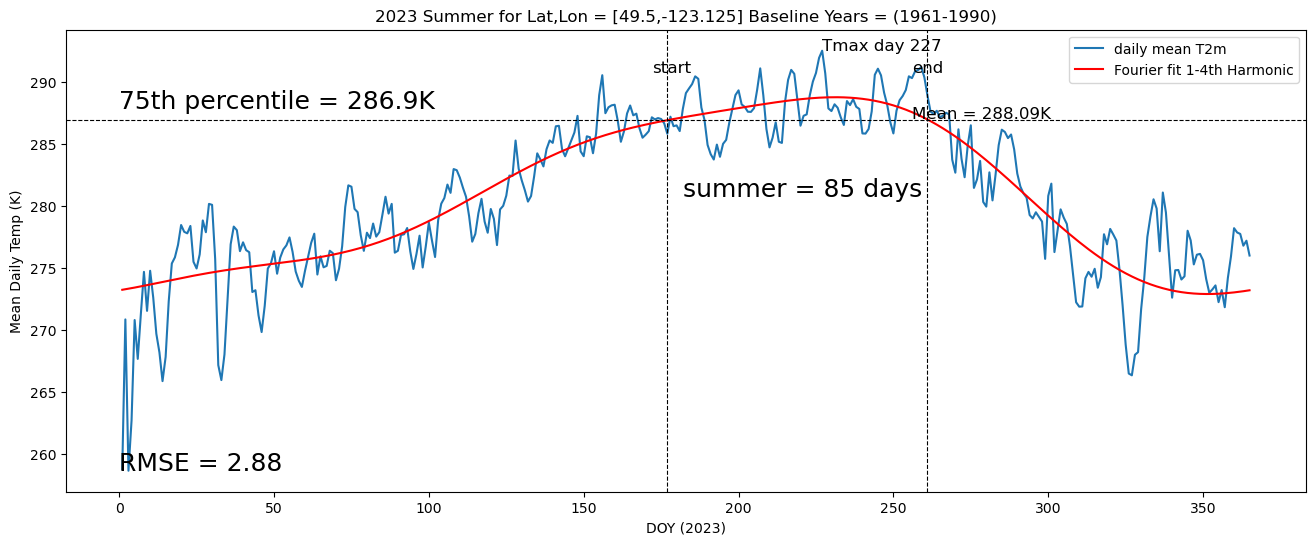

CPU times: user 821 ms, sys: 126 ms, total: 947 ms
Wall time: 794 ms


(177,
 261,
 227,
 133.20101928710938,
 85,
 2.8821969032287598,
 0.0,
 288.0919189453125,
 2.183623267001792)

In [66]:
%%time
input_year = 2023

ds = ds_gfdl.sel(time = str(input_year))
curr = ds.tas.sel(lat=input_lat, lon=input_lon, method="nearest")
dsnext = ds_gfdl.sel(time = str(input_year+1))
nxt = dsnext.tas.sel(lat=input_lat, lon=input_lon, method="nearest")
start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs = SummerStatsFourier(curr, nxt, thresh, True, True, True)
start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs

### Try Sydney Australia to test SH functioning

In [67]:
input_lat = -33 - 52/60 - 4/3600
input_lon = 151.25
thresh = c_75.sel(lat=input_lat, lon=input_lon, method="nearest")

curr = ds.tas.sel(lat=input_lat, lon=input_lon, method="nearest")
nxt = dsnext.tas.sel(lat=input_lat, lon=input_lon, method="nearest")
curr, nxt

(<xarray.DataArray 'tas' (time: 365)> Size: 1kB
 dask.array<getitem, shape=(365,), dtype=float32, chunksize=(1,), chunktype=numpy.ndarray>
 Coordinates:
   * time     (time) datetime64[ns] 3kB 2023-01-01T12:00:00 ... 2023-12-31T12:...
     height   float64 8B 2.0
     lat      float64 8B -33.5
     lon      float64 8B 151.9
 Attributes:
     long_name:      Near-Surface Air Temperature
     units:          K
     cell_methods:   area: time: mean
     cell_measures:  area: areacella
     standard_name:  air_temperature
     interp_method:  conserve_order2
     original_name:  tas,
 <xarray.DataArray 'tas' (time: 365)> Size: 1kB
 dask.array<getitem, shape=(365,), dtype=float32, chunksize=(1,), chunktype=numpy.ndarray>
 Coordinates:
   * time     (time) datetime64[ns] 3kB 2024-01-01T12:00:00 ... 2024-12-31T12:...
     height   float64 8B 2.0
     lat      float64 8B -33.5
     lon      float64 8B 151.9
 Attributes:
     long_name:      Near-Surface Air Temperature
     units:          K
 

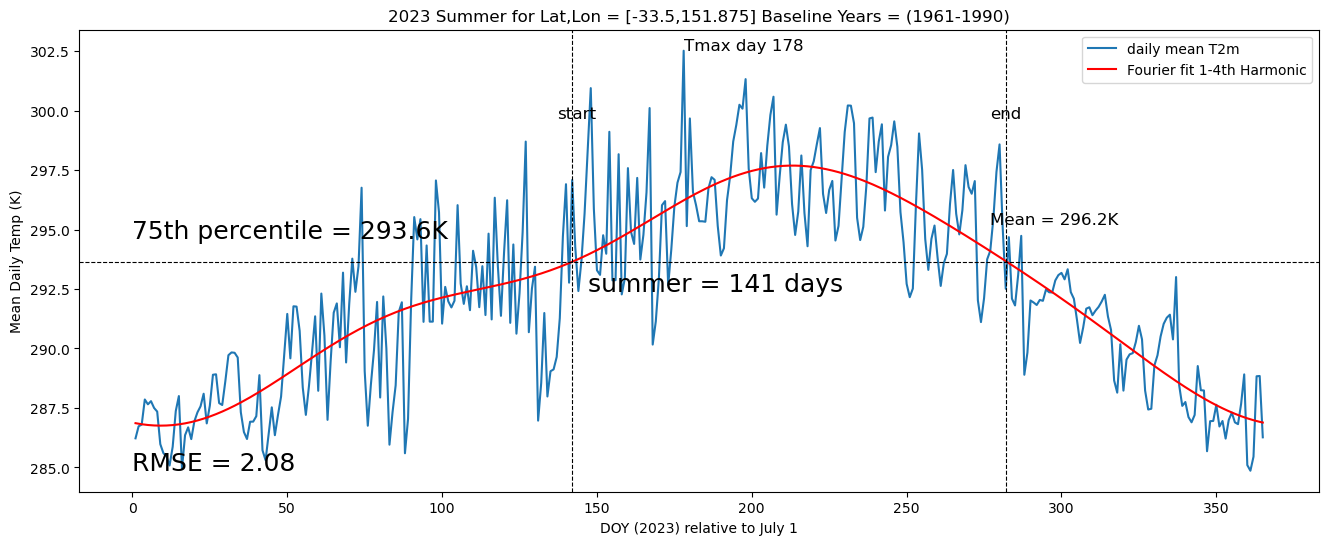

(142,
 282,
 178,
 387.9443359375,
 141,
 2.0770905017852783,
 0.0,
 296.19970703125,
 3.2328694661458144)

In [68]:
start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs = SummerStatsFourier(curr, nxt, thresh, True, True, True)
start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs

## Main Loop: loop through multiple years to generate summer stats

In [69]:
# grid parameters for looping
num_lat = ds_gfdl.lat.shape[0]
num_lon = ds_gfdl.lon.shape[0]

loop_lats = ds_gfdl.lat.values[:num_lat]
loop_lons = ds_gfdl.lon.values[:num_lon]
loop_lats, loop_lons

(array([-89.5, -88.5, -87.5, -86.5, -85.5, -84.5, -83.5, -82.5, -81.5,
        -80.5, -79.5, -78.5, -77.5, -76.5, -75.5, -74.5, -73.5, -72.5,
        -71.5, -70.5, -69.5, -68.5, -67.5, -66.5, -65.5, -64.5, -63.5,
        -62.5, -61.5, -60.5, -59.5, -58.5, -57.5, -56.5, -55.5, -54.5,
        -53.5, -52.5, -51.5, -50.5, -49.5, -48.5, -47.5, -46.5, -45.5,
        -44.5, -43.5, -42.5, -41.5, -40.5, -39.5, -38.5, -37.5, -36.5,
        -35.5, -34.5, -33.5, -32.5, -31.5, -30.5, -29.5, -28.5, -27.5,
        -26.5, -25.5, -24.5, -23.5, -22.5, -21.5, -20.5, -19.5, -18.5,
        -17.5, -16.5, -15.5, -14.5, -13.5, -12.5, -11.5, -10.5,  -9.5,
         -8.5,  -7.5,  -6.5,  -5.5,  -4.5,  -3.5,  -2.5,  -1.5,  -0.5,
          0.5,   1.5,   2.5,   3.5,   4.5,   5.5,   6.5,   7.5,   8.5,
          9.5,  10.5,  11.5,  12.5,  13.5,  14.5,  15.5,  16.5,  17.5,
         18.5,  19.5,  20.5,  21.5,  22.5,  23.5,  24.5,  25.5,  26.5,
         27.5,  28.5,  29.5,  30.5,  31.5,  32.5,  33.5,  34.5,  35.5,
      

In [70]:
# process_yrs = [1990,1991,1992,1993, 1994, 1995, 1996, 1997, 1998, 1999, 2002, 2004, 2005, 2006, 2007, 2008,
#               2009, 2010, 2011, 2012, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
process_yrs = np.arange(1990, 1991,1)

process_yrs

array([1990])

In [ ]:
%%time

# Runtime: 32.5 min for 1 year
# 3h 19m for 6 years
# 8h 50m hrs for 16 years

# loop thru the years in the defined array above
for input_year in process_yrs:

    start = dt.now()

    ds = ds_gfdl.sel(time = str(input_year))

    dsnext = ds_gfdl.sel(time = str(input_year+1))

    # load into memory to speed up the summer stats processing
    ds.load()
    dsnext.load()

    # empty data arrays for summer stats
    summerlength = xr.DataArray(np.zeros((num_lat,num_lon)), 
                                coords=[loop_lats, loop_lons], 
                                dims=['lat','lon'])
    summerstart = xr.DataArray(np.zeros((num_lat,num_lon)), 
                               coords=[loop_lats, loop_lons], 
                               dims=['lat','lon'])
    summerend = xr.DataArray(np.zeros((num_lat,num_lon)), 
                             coords=[loop_lats, loop_lons], 
                             dims=['lat','lon'])
    summermax = xr.DataArray(np.zeros((num_lat,num_lon)), 
                             coords=[loop_lats, loop_lons], 
                             dims=['lat','lon'])
    summerheat = xr.DataArray(np.zeros((num_lat,num_lon)), 
                             coords=[loop_lats, loop_lons], 
                             dims=['lat','lon'])
    summerrmse = xr.DataArray(np.zeros((num_lat,num_lon)), 
                             coords=[loop_lats, loop_lons], 
                             dims=['lat','lon'])
    summerr2 = xr.DataArray(np.zeros((num_lat,num_lon)), 
                             coords=[loop_lats, loop_lons], 
                             dims=['lat','lon'])
    summermean = xr.DataArray(np.zeros((num_lat,num_lon)), 
                             coords=[loop_lats, loop_lons], 
                             dims=['lat','lon'])
    summermeanhs = xr.DataArray(np.zeros((num_lat,num_lon)), 
                             coords=[loop_lats, loop_lons], 
                             dims=['lat','lon'])
    
    # add attributes
    summerstart.attrs["long_name"] = "Start day of summer for the year (DOY in [1,365])"
    summerstart.attrs["units"] = "Day of year"
    
    summerend.attrs["long_name"] = "Last day of summer for the year (DOY in [1,365])"
    summerend.attrs["units"] = "Day of year"
    
    summerlength.attrs["long_name"] = "Duration of summer for the year"
    summerlength.attrs["units"] = "Days"
    
    summermax.attrs["long_name"] = "Day of max mean temp during summer for the year"
    summermax.attrs["units"] = "Day of year"
    
    summerheat.attrs["long_name"] = "Accumulated heat during summer for the year"
    summerheat.attrs["units"] = "Degree-Days"
    
    summerrmse.attrs["long_name"] = "Root mean squared error of Fourier fit"
    summerrmse.attrs["units"] = "Degrees [K]"
    
    summerr2.attrs["long_name"] = "Coefficient of determination (R-squared) of Fourier fit [NOT USED]"
    summerr2.attrs["units"] = "Variance explained"

    summermean.attrs["long_name"] = "Mean temperature during the summer period"
    summermean.attrs["units"] = "Degrees [K]"

    summermeanhs.attrs["long_name"] = "Mean HS temperature during the summer period"
    summermeanhs.attrs["units"] = "Degrees [K]"

    ## now that I've added RMSE and R^2 - these loops take ~27 min with heat and tmax

    # loop through all of the lat,lon of interest
    for input_lat in loop_lats:
        for input_lon in loop_lons:
            # get threshold from c_75 - using closest location since not same grid as GFDL-ESM4
            thresh = c_75.sel(lat=input_lat,lon=input_lon, method='nearest')
    
            # all the temps for that grid cell over time for this year and next (for SH)
            curr = ds.tas.sel(lat=input_lat,lon=input_lon) 
            nxt = dsnext.tas.sel(lat=input_lat, lon=input_lon)
    
            # build summer stats for the grid cell and produce the plot if desired (currently False)
            start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs = SummerStatsFourier(curr, nxt, thresh, False, True, True)
            
            # xarray requires strange indexing in order to replace values by coordinate
            summerstart.loc[input_lat, input_lon] = start_day
            summerend.loc[input_lat, input_lon] = last_day
            summermax.loc[input_lat, input_lon] = day_of_max
            summerheat.loc[input_lat, input_lon] = acc_heat
            summerlength.loc[input_lat, input_lon] = summer_length
            summerrmse.loc[input_lat, input_lon] = rmse
            summerr2.loc[input_lat, input_lon] = r2
            summermean.loc[input_lat, input_lon] = mean_temp
            summermeanhs.loc[input_lat, input_lon] = mean_hs
            

    # save it out
    sum_ds = xr.Dataset(data_vars={'SummerStart':summerstart,
                               'SummerEnd':summerend,
                               'SummerTmax':summermax,
                               'SummerHeat':summerheat,
                               'SummerLength':summerlength,
                               'SummerRMSE':summerrmse,
                               'SummerR2':summerr2,
                                'SummerMeanT':summermean,
                                   'SummerMeanHS':summermeanhs})
    output_path = '../../../Data/CMIP6/GFDL-ESM4/Summers/'+str(input_year)+'_GFDL-ESM4_r1i1p1f1_summer_stats.nc'
    sum_ds.to_netcdf(output_path)

    # plots for the year
    ##############
    # Global summer mean temp for the year
    # fig = plt.figure(figsize=(12,6))
    
    # # assign axis and def projection to use
    # ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))
    
    # # add coastlines and grid
    # ax.coastlines()
    # ax.gridlines()
    
    # sum_ds.SummerMeanT.plot(
    #     ax=ax,
    #     transform=ccrs.PlateCarree(), # assign map projection
    #     vmin=250,
    #     vmax=320, # define range to include an entire year
    #     cmap="coolwarm"#"YlOrRd"#cmap="coolwarm"
    # )
    
    # plt.title("Summer Mean Temp for "+str(input_year))#+" using 1961-1990 baseline")
    # #plt.savefig("./Plots/"+str(input_year)+"_SummerMeanHS_global.png")
    # plt.show()

    end = dt.now()
    elapsed = (end-start).total_seconds()/60.0
    print("Time for "+str(input_year)+" :"+str(elapsed)+" min")